# MMP9 Hit Docking Pipeline

This notebook implements a molecular docking workflow for MMP9 QSAR hits.
It takes compounds exported from SwissADME, applies diversity filtering,
generates 3-D conformers, prepares the receptor (PDB: **1GKC**, the
hydroxamate-bound MMP9 crystal structure), and runs **AutoDock Vina** to
rank the hits by predicted binding affinity.

**Pipeline overview**
1. Load & clean SMILES from SwissADME export  
2. Diversity filtering (Tanimoto threshold = 0.50)  
3. 3-D conformer generation (ETKDGv3 + MMFF)  
4. PDBQT conversion via Meeko  
5. Receptor preparation (1GKC chain A + catalytic Zn)  
6. AutoDock Vina docking  
7. Results visualisation

## 1. Imports

In [1]:
import os
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.DataStructs import TanimotoSimilarity
from meeko import MoleculePreparation, PDBQTWriterLegacy


## 2. Load & clean SMILES

Load the SwissADME CSV and keep only rows with valid SMILES strings.
This is the set of compounds that passed ADMET pre-filtering.

In [2]:
df = pd.read_csv("swissadme.csv")
df = df[df["Canonical SMILES"].notna()]
df = df[df["Canonical SMILES"].apply(lambda x: isinstance(x, str))]
smiles_list = df["Canonical SMILES"].tolist()

print(f"Compounds loaded: {len(df)}")
df.head(3)


Compounds loaded: 20


,Molecule,Canonical SMILES,Formula,MW,#Heavy atoms,#Aromatic heavy atoms,Fraction Csp3,#Rotatable bonds,#H-bond acceptors,#H-bond donors,...,Lipinski #violations,Ghose #violations,Veber #violations,Egan #violations,Muegge #violations,Bioavailability Score,PAINS #alerts,Brenk #alerts,Leadlikeness #violations,Synthetic Accessibility
0,Molecule 1,ONC(=O)/C=C/c1cccc(c1)S(=O)(=O)Nc1ccccc1,C15H14N2O4S,318.35,22.0,12.0,0.00,6.0,4.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.55,0.0,3.0,0.0,2.94
1,Molecule 2,CN1CCC[C@@H]1Cc1c[nH]c2c1cc(cc2)CCS(=O)(=O)c1c...,C22H26N2O2S,382.52,27.0,15.0,0.36,6.0,3.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.55,0.0,0.0,2.0,3.53
2,Molecule 3,CN1CCC[C@@H]1Cc1c[nH]c2c1cc(cc2)CCS(=O)(=O)c1c...,C22H27BrN2O2S,463.43,28.0,15.0,0.36,6.0,3.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.55,0.0,0.0,2.0,3.62


## 3. Diversity filtering (Tanimoto, threshold = 0.50)

We compute ECFP4 (Morgan radius-2, 2048 bits) fingerprints and apply a
greedy maximum-dissimilarity selection: a compound is kept only if its
maximum Tanimoto similarity to any already-selected compound is **below
0.50**, ensuring structural diversity in the docking set.

> **Note:** RDKit deprecated `GetMorganFingerprintAsBitVect`; we use the
> current `MorganGenerator` API instead.

In [3]:
# Build ECFP4 fingerprints with the current (non-deprecated) API
morgan_gen = AllChem.GetMorganGenerator(radius=2, fpSize=2048)
mols = [Chem.MolFromSmiles(s) for s in smiles_list]
fps  = [morgan_gen.GetFingerprint(m) for m in mols]

# Greedy max-dissimilarity selection
TANIMOTO_THRESHOLD = 0.50
selected_idx = []
selected_fps = []

for i, fp in enumerate(fps):
    if not selected_fps:
        selected_idx.append(i)
        selected_fps.append(fp)
    else:
        sims = [TanimotoSimilarity(fp, sfp) for sfp in selected_fps]
        if max(sims) < TANIMOTO_THRESHOLD:
            selected_idx.append(i)
            selected_fps.append(fp)

print(f"Before filtering : {len(df)} compounds")
print(f"After filtering  : {len(selected_idx)} compounds  "
      f"(Tanimoto threshold = {TANIMOTO_THRESHOLD})")


Before filtering : 20 compounds
After filtering  : 16 compounds  (Tanimoto threshold = 0.5)


### 3.1 Sanity-check: near-duplicate detection

Inspect pairwise Tanimoto scores among the first five candidates to confirm
the greedy filter is working as expected.  Pairs with similarity ≥ 0.50
should not both appear in the selected set.

In [4]:
print("Pairwise Tanimoto similarities (first 5 compounds):")
for i in range(5):
    for j in range(i + 1, 5):
        sim = TanimotoSimilarity(fps[i], fps[j])
        flag = "  ← NEAR-DUPLICATE" if sim >= TANIMOTO_THRESHOLD else ""
        print(f"  ({i}, {j})  Tanimoto = {sim:.4f}{flag}")


Pairwise Tanimoto similarities (first 5 compounds):
  (0, 1)  Tanimoto = 0.1519
  (0, 2)  Tanimoto = 0.1500
  (0, 3)  Tanimoto = 0.1525
  (0, 4)  Tanimoto = 0.0833
  (1, 2)  Tanimoto = 0.9815  ← NEAR-DUPLICATE
  (1, 3)  Tanimoto = 0.1067
  (1, 4)  Tanimoto = 0.1522
  (2, 3)  Tanimoto = 0.1053
  (2, 4)  Tanimoto = 0.1505
  (3, 4)  Tanimoto = 0.2388


Compounds 1 and 2 have Tanimoto ≈ 0.98 — nearly identical.  The greedy
filter already excluded one; we drop the remaining near-duplicate manually
to confirm the final diversity set is clean.

In [5]:
# Drop the near-duplicate (original index 2) identified above
df_diverse = df.drop(index=2).reset_index(drop=True)

print(f"Final diverse set: {len(df_diverse)} compounds")


Final diverse set: 19 compounds


## 4. 3-D conformer generation

For each compound in the diverse set we:
1. Extract the largest fragment (removes salt counterions such as HCl, MeSO₄).
2. Add explicit hydrogens.
3. Embed with **ETKDGv3** (best-practice for drug-like molecules); fall back
   to ETKDG if ETKDGv3 fails.
4. Minimise with MMFF94.
5. Write to `ligands_sdf/ligand_<i>.sdf`.

In [10]:
os.makedirs("ligands_sdf", exist_ok=True)

def get_largest_fragment(mol):
    """Return the largest fragment (by heavy-atom count) from a mol object."""
    frags = Chem.GetMolFrags(mol, asMols=True)
    return max(frags, key=lambda m: m.GetNumHeavyAtoms())

failed = []

for i, row in df_diverse.iterrows():
    mol = Chem.MolFromSmiles(row["Canonical SMILES"])
    mol = get_largest_fragment(mol)
    mol = Chem.AddHs(mol)

    # Try ETKDGv3 first, fall back to ETKDG
    result = AllChem.EmbedMolecule(mol, AllChem.ETKDGv3())
    if result == -1:
        result = AllChem.EmbedMolecule(mol, AllChem.ETKDG())

    if result == -1:
        print(f"Ligand {i} — embedding failed: {row['Canonical SMILES'][:50]}")
        failed.append(i)
        continue

    AllChem.MMFFOptimizeMolecule(mol)

    writer = Chem.SDWriter(f"ligands_sdf/ligand_{i}.sdf")
    writer.write(mol)
    writer.close()

print(f"\nGenerated : {len(df_diverse) - len(failed)} / {len(df_diverse)}")
print(f"Failed    : {failed}")


Ligand 4 — embedding failed: CS(=O)(=O)O.O=C1CN2[C@H]3C[C@H]1C[C@@H]2C[C@@H](C3

Generated : 18 / 19
Failed    : [4]


## 5. PDBQT conversion (Meeko)

AutoDock Vina requires ligands in **PDBQT** format.  We use Meeko's
`MoleculePreparation` + `PDBQTWriterLegacy` to convert each SDF to PDBQT.

In [11]:
os.makedirs("ligands_pdbqt", exist_ok=True)

preparator = MoleculePreparation()

for i in range(len(df_diverse)):
    if i in failed:
        continue

    sdf_path   = f"ligands_sdf/ligand_{i}.sdf"
    pdbqt_path = f"ligands_pdbqt/ligand_{i}.pdbqt"

    mol = Chem.SDMolSupplier(sdf_path, removeHs=False)[0]
    if mol is None:
        print(f"Could not read ligand {i}")
        continue

    mol_setups = preparator.prepare(mol)
    pdbqt_string, is_ok, error = PDBQTWriterLegacy.write_string(mol_setups[0])

    if not is_ok:
        print(f"Ligand {i} PDBQT failed: {error}")
        continue

    with open(pdbqt_path, "w") as f:
        f.write(pdbqt_string)

print("All ligands converted.")


All ligands converted.


## 6. Receptor preparation (PDB: 1GKC)

We use **1GKC** — the MMP9 catalytic domain co-crystallised with the
hydroxamate inhibitor **NFH** — as the docking receptor.  NFH occupies the
active site, so its centroid gives us a reliable docking-box centre.

Steps:
1. Download 1GKC from RCSB.
2. Identify the co-crystallised NFH inhibitor coordinates → docking-box centre.
3. Keep chain A ATOM records + catalytic Zn; strip chain B, waters, NFH, Ca²⁺.
4. Run `prepare_receptor4.py` (AutoDockTools) to add Gasteiger charges and
   produce `1GKC.pdbqt`.

In [15]:
# --- 6.1  Download 1GKC ---------------------------------------------------
PDB_ID = "1GKC"
url    = f"https://files.rcsb.org/download/{PDB_ID}.pdb"
r      = requests.get(url)

with open(f"receptor/{PDB_ID}.pdb", "w") as f:
    f.write(r.text)

lines = r.text.splitlines()

# Summarise contents
hetatm_info = set()
for line in lines:
    if line.startswith("HETATM"):
        hetatm_info.add((line[17:20].strip(), line[21]))

atom_count = sum(1 for l in lines if l.startswith("ATOM"))
print(f"Downloaded {PDB_ID}.pdb")
print(f"ATOM records   : {atom_count}")
print(f"HETATM residues: {sorted(hetatm_info)}")


Downloaded 1GKC.pdb
ATOM records   : 2512
HETATM residues: [('CA', 'A'), ('CA', 'B'), ('HOH', 'A'), ('HOH', 'B'), ('NFH', 'A'), ('NFH', 'B'), ('ZN', 'A'), ('ZN', 'B')]


In [16]:
# --- 6.2  Derive docking-box centre from NFH inhibitor --------------------
# NFH = the hydroxamate inhibitor co-crystallised in the active site of 1GKC.
# Its centroid is used as the search-box centre for AutoDock Vina.

nfh_coords = []
for line in lines:
    if line.startswith("HETATM") and line[17:20].strip() == "NFH" and line[21] == "A":
        x, y, z = float(line[30:38]), float(line[38:46]), float(line[46:54])
        nfh_coords.append((x, y, z))

nfh_coords = np.array(nfh_coords)
center     = nfh_coords.mean(axis=0)

center_x, center_y, center_z = center
print(f"Docking-box centre — x={center_x:.3f}, y={center_y:.3f}, z={center_z:.3f}")


Docking-box centre — x=65.839, y=30.707, z=117.746


In [17]:
# --- 6.3  Clean receptor: chain A + catalytic Zn --------------------------
clean_lines = []
for line in lines:
    if line.startswith("ATOM") and line[21] == "A":
        clean_lines.append(line)
    elif line.startswith("HETATM") and line[17:20].strip() == "ZN" and line[21] == "A":
        clean_lines.append(line)   # keep catalytic zinc
    elif line.startswith(("END", "TER")):
        clean_lines.append(line)

with open("receptor/1GKC_clean.pdb", "w") as f:
    f.write("\n".join(clean_lines))

print(f"Clean receptor saved — {len(clean_lines)} lines")
print("Kept    : chain A ATOM records + catalytic Zn")
print("Stripped: chain B, waters (HOH), NFH inhibitor, Ca²⁺ ions")


Clean receptor saved — 1276 lines
Kept    : chain A ATOM records + catalytic Zn
Stripped: chain B, waters (HOH), NFH inhibitor, Ca²⁺ ions


In [23]:
# --- 6.4  Convert to PDBQT via prepare_receptor4.py ----------------------
import sys

PREPARE_RECEPTOR = (
    r"C:\Users\LAPTOP LAB\AppData\Local\Programs\Python\Python311"
    r"\Lib\site-packages\AutoDockTools\Utilities24\prepare_receptor4.py"
)

result = subprocess.run(
    [sys.executable, PREPARE_RECEPTOR,
     "-r", "receptor/1GKC_clean.pdb",
     "-o", "receptor/1GKC.pdbqt",
     "-A", "hydrogens",
     "-U", "waters"],
    capture_output=True, text=True
)

if result.returncode != 0:
    print("STDERR:", result.stderr)
    raise RuntimeError("prepare_receptor4 failed")

if result.stdout.strip():
    print("STDOUT:", result.stdout.strip())

size_kb = os.path.getsize("receptor/1GKC.pdbqt") / 1024
print(f"receptor/1GKC.pdbqt created ({size_kb:.1f} KB)")


STDOUT: Sorry, there are no Gasteiger parameters available for atom 1GKC_clean:A: ZN1450:ZN
Sorry, there are no Gasteiger parameters available for atom 1GKC_clean:A: ZN1451:ZN
receptor/1GKC.pdbqt created (194.2 KB)


## 7. AutoDock Vina docking

We dock all prepared ligands against the clean 1GKC receptor using a
20 Å × 20 Å × 20 Å search box centred on the NFH binding site.

| Parameter | Value |
|-----------|-------|
| Exhaustiveness | 8 |
| Num modes | 5 |
| Box size | 20 Å × 20 Å × 20 Å |

In [25]:
os.makedirs("ligands", exist_ok=True)

VINA_EXE = "vina.exe"
RECEPTOR  = "receptor/1GKC.pdbqt"
BOX_SIZE  = 20

results = []

for i in range(len(df_diverse)):
    if i in failed:
        continue

    ligand = f"ligands_pdbqt/ligand_{i}.pdbqt"
    out    = f"ligands/ligand_{i}_out.pdbqt"

    cmd = [
        VINA_EXE,
        "--receptor", RECEPTOR,
        "--ligand",   ligand,
        "--center_x", str(center_x),
        "--center_y", str(center_y),
        "--center_z", str(center_z),
        "--size_x",   str(BOX_SIZE),
        "--size_y",   str(BOX_SIZE),
        "--size_z",   str(BOX_SIZE),
        "--exhaustiveness", "8",
        "--num_modes",      "5",
        "--out", out,
    ]

    proc = subprocess.run(cmd, capture_output=True, text=True)

    if proc.returncode == 0:
        best_score = None
        for line in proc.stdout.split("\n"):
            if line.strip().startswith("1 "):
                best_score = float(line.split()[1])
                break
        results.append({"ligand": i, "score": best_score})
        print(f"Ligand {i:>2d}: {best_score:>7.3f} kcal/mol")
    else:
        print(f"Ligand {i} FAILED: {proc.stderr[:80]}")

print("\nDocking complete.")


Ligand  0: -10.050 kcal/mol
Ligand  1:  -9.038 kcal/mol
Ligand  2:  -8.172 kcal/mol
Ligand  3:  -9.203 kcal/mol
Ligand  5:  -7.795 kcal/mol
Ligand  6:  -7.594 kcal/mol
Ligand  7:  -8.446 kcal/mol
Ligand  8:  -8.211 kcal/mol
Ligand  9:  -8.606 kcal/mol
Ligand 10:  -8.133 kcal/mol
Ligand 11:  -6.616 kcal/mol
Ligand 12:  -9.978 kcal/mol
Ligand 13:  -9.699 kcal/mol
Ligand 14:  -8.763 kcal/mol
Ligand 15:  -8.915 kcal/mol
Ligand 16:  -9.649 kcal/mol
Ligand 17:  -8.392 kcal/mol
Ligand 18:  -8.472 kcal/mol

Docking complete.


## 8. Results

Rank compounds by docking score (most negative = strongest predicted binder).
Colour code: **green** ≤ −9 kcal/mol | **orange** −9 to −8 | **red** > −8.

In [26]:
results_df = pd.DataFrame(results).sort_values("score").reset_index(drop=True)
results_df["smiles"] = results_df["ligand"].apply(
    lambda i: df_diverse.iloc[i]["Canonical SMILES"]
)
results_df["compound_name"] = results_df["ligand"].apply(
    lambda i: df_diverse.iloc[i].get("Molecule ChEMBL ID", f"ligand_{i}")
)

print(results_df[["compound_name", "score", "smiles"]].to_string())


   compound_name   score                                                                smiles
0       ligand_0 -10.050                              ONC(=O)/C=C/c1cccc(c1)S(=O)(=O)Nc1ccccc1
1      ligand_12  -9.978                         ONC(=O)/C=C/c1ccc(cc1)CNCCc1c(C)[nH]c2c1cccc2
2      ligand_13  -9.699  Cc1ccc(cc1)S(=O)(=O)O.C=CC(=O)N1C[C@@H](CC[C@@H]1C)Nc1ncnc2c1cc[nH]2
3      ligand_16  -9.649              COc1cc2ncnc(c2cc1NC(=O)/C=C/CN1CCCCC1)Nc1ccc(c(c1)Cl)F.O
4       ligand_3  -9.203                    CC(COc1ccc(cc1)CNC(=O)N(C1CCN(CC1)C)Cc1ccc(cc1)F)C
5       ligand_1  -9.038                   CN1CCC[C@@H]1Cc1c[nH]c2c1cc(cc2)CCS(=O)(=O)c1ccccc1
6      ligand_15  -8.915                CCCCCCCC(=O)N[C@@H]([C@@H](c1ccc2c(c1)OCCO2)O)CN1CCCC1
7      ligand_14  -8.763         O=C1CC[C@H](N1)C(=O)N[C@H](C(=O)N1CCC[C@H]1C(=O)N)Cc1nc[nH]c1
8       ligand_9  -8.606                CN1CCN(CC1)CC/C=C\1/c2ccccc2Sc2c1cc(cc2)S(=O)(=O)N(C)C
9      ligand_18  -8.472                       CNS

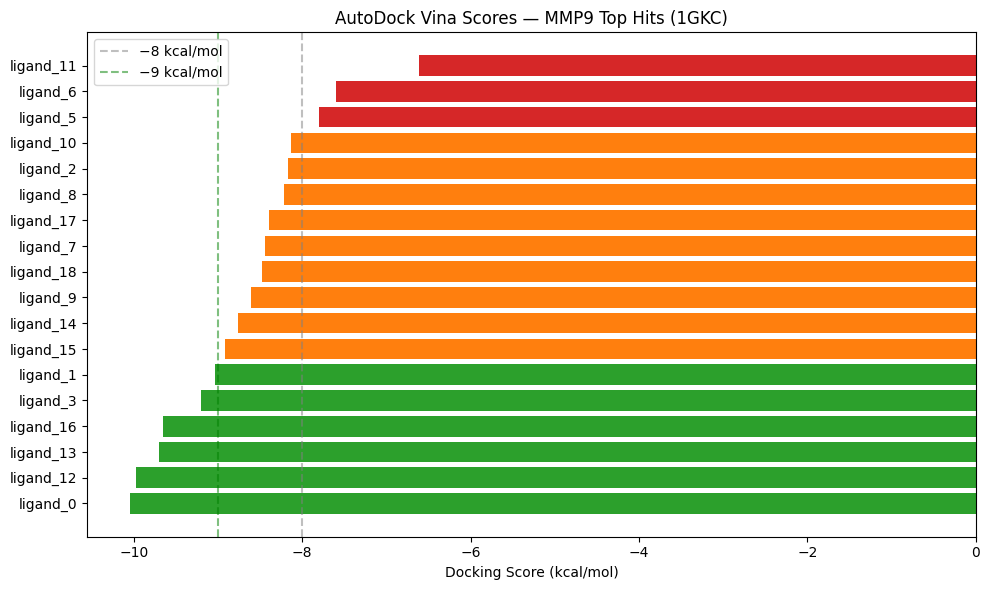

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = [
    "#2ca02c" if s <= -9 else "#ff7f0e" if s <= -8 else "#d62728"
    for s in results_df["score"]
]

ax.barh(results_df["compound_name"], results_df["score"], color=colors)
ax.axvline(x=-8, color="gray",  linestyle="--", alpha=0.5, label="−8 kcal/mol")
ax.axvline(x=-9, color="green", linestyle="--", alpha=0.5, label="−9 kcal/mol")
ax.set_xlabel("Docking Score (kcal/mol)")
ax.set_title("AutoDock Vina Scores — MMP9 Top Hits (1GKC)")
ax.legend()
plt.tight_layout()
plt.savefig("docking_scores.png", dpi=150)
plt.show()


In [28]:
results_df.to_csv("results_df.csv")